In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from natsort import natsorted
import yaml
import os

%matplotlib inline

In [2]:
from libs.mapper.create_topomap import CostmapData
from libs.control.learnt_controller import ObjRelLearntController, visualize_prediction
from notebooks.viz_utils import plot_query_img_costmap_waypoints, plot_query_img_with_costmap

/scratch2/utkarsh.malaiya/pixi-envs/envs/mast3r-nav-8518414631565413830/envs/default/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
SCENE_DIR = Path("./data/gs2_modified/img_L_1preF")

SCENE_IMG_DIR = SCENE_DIR / "images"
MAP_BASE_DIR = Path(os.path.abspath("./outputs/gs2_mapping_v1"))

SCENE_NAME = "img_L_1preF"
SCENE_MAP_DIR = MAP_BASE_DIR / SCENE_NAME

costmaps_file = SCENE_MAP_DIR / "costmaps_320x240_EC_NONE_NC_NONE_NCF_10.npz"

costmaps_data = np.load(costmaps_file)
# print("Costmaps data keys:", costmaps_data.files)
img_costmaps = costmaps_data["costmaps"]

img_paths = natsorted(SCENE_IMG_DIR.iterdir())

In [4]:
from hydra import compose, initialize
from omegaconf import OmegaConf

with initialize(version_base=None, config_path="configs/controller"):
    config = dict(compose(config_name="gs2_learnt"))

print(OmegaConf.to_yaml(config))

load_run: /home2/utkarsh.malaiya/mast3r-nav/checkpoints/gnm-mast3r-nav
predict_dists: true
goal_type: image_mask_enc
goal_value_granularity: pixel
goal_use_pl: 1
obs_type: disabled
dims_segFt: 8
precomp: 2
goal_uses_context: true
goal_uses_stacked_context: false
is_pl_normalized: false
use_vel_filter: false
use_mask_grad: false
close_threshold: 3
loc_radius: 4
waypoint_index: 5
fixed_plan: false
model_type: gnm
obs_encoding_size: 1024
goal_encoding_size: 1024
normalize: true
context_type: temporal
context_size: 5
alpha: 0.5
distance:
  min_dist_cat: 0
  max_dist_cat: 20
action:
  min_dist_cat: 2
  max_dist_cat: 10
close_far_threshold: 10
len_traj_pred: 10
learn_angle: true
image_size:
- 320
- 240
graphs_path: ./outputs/gs2_mapping_v1
print_log_freq: 100
image_log_freq: 1000
num_images_log: 8
pairwise_test_freq: 20
wandb_log_freq: 10
eval_freq: 1
name: gs2_learnt
boost_final_goal: false
v_min: 0.05
v_max: 0.2
w_min: -0.3
w_max: 0.3



In [5]:
config['boost_final_goal'] = config.get('boost_final_goal', False)
controller = ObjRelLearntController(
    config=config,
    boost_final_goal=config['boost_final_goal']
)
controller

Loading model from  /home2/utkarsh.malaiya/mast3r-nav/checkpoints/gnm-mast3r-nav
Learnt controller initialized!


In [6]:
controller.reset_params()

In [7]:
waypoints = []

for idx, img_path in enumerate(img_paths):
    bgr = cv2.imread(str(img_path))
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)  # (H, W, 3) uint8
    # Corresponding costmap for this frame (pixel-wise path lengths)
    costmap = img_costmaps[idx]  # (H, W) float32
    # Run controller — goal_data is just the costmap (H, W)
    v, w, _ = controller.predict(rgb, costmap)
    waypoints.append(controller.action_pred.copy())
    # plt.imshow(rgb)
    # plt.show()
    # print(v, w, _)
    # break

waypoints = np.array(waypoints)  # (N_frames, len_traj_pred, 4)
print(f"Collected waypoints: {waypoints.shape}")  # e.g. (N, 10, 4)


Collected waypoints: (174, 10, 4)


In [8]:
save_path = MAP_BASE_DIR / "waypoints_gs2_traj1_test.npz"
np.savez_compressed(
    save_path,
    waypoints=waypoints,                           # (N, T, 4)
    img_paths=np.array([str(p) for p in img_paths]),  # (N,) string paths
)
print(f"Saved to {save_path.resolve()}")


Saved to /home2/utkarsh.malaiya/mast3r-nav/outputs/gs2_mapping_v1/waypoints_gs2_traj1_test.npz


In [12]:
output_imgs_dir = MAP_BASE_DIR / "outputs_viz"
if not output_imgs_dir.exists(): 
    os.makedirs(output_imgs_dir)

for idx, path in enumerate(img_paths):
    img = cv2.cvtColor(cv2.imread(str(img_paths[idx])), cv2.COLOR_BGR2RGB)
    costmap  = img_costmaps[idx]
    traj = waypoints[idx]   # (len_traj_pred, 4)
    plot_query_img_costmap_waypoints(
        query_img=img,
        costmap=costmap,
        waypoints=traj,
        step_id=idx,
        nan_threshold=99,      # mask out outlier / unreachable cells (pl >= 99)
        use_percentile=True,   # 5th–95th %ile for cleaner colour scale
        save_path=output_imgs_dir / f"img_costmap_traj_{idx:03}.jpg"
)

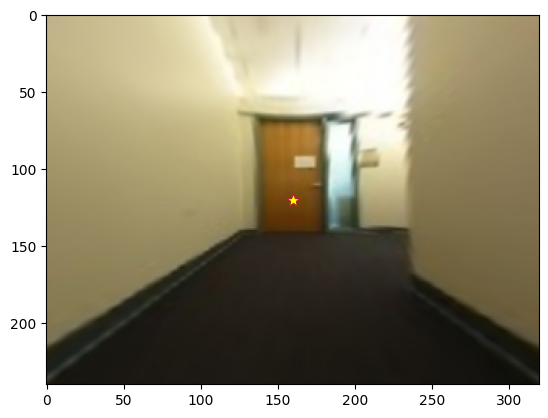

In [21]:
%matplotlib inline

# Visualize goal, which for the gostanford run is img idx 50, pixel location (160, 120)
# from PIL import Image
# img = img_paths[50]
img = cv2.cvtColor(cv2.imread(str(img_paths[50])), cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (320, 240))
plt.imshow(img)
plt.plot(160, 120, marker='*', markersize=10, markerfacecolor="yellow", markeredgecolor="brown")
plt.savefig(MAP_BASE_DIR / "outputs_viz" / "goal_img.jpg")
plt.show()
# for img in img_paths:
#     print(img)